# Completitud de songs_final.csv

Una mirada rápida a qué tan lleno quedó el CSV final después de todo el ETL.
La idea es tener números y un par de gráficas para el informe, nada más.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/songs_final.csv")
df.shape

(100000, 38)

In [2]:
df_antiguo = pd.read_csv("../data/grupo_5.csv")
df_antiguo.shape

(100000, 7)

Se agregaron 31 columnas de información para cada canción

In [3]:
df.head(3)

,track_id,title,artist_name,release,year,duration,artist_mbid,recording_mbid,metodo_match,anio,...,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,key_key,key_scale,tuning_frequency,tuning_equal_tempered_deviation
0,TRAAADJ128F4287B47,Heartache People,Big Brother & The Holding Company,Be a Brother,1970,396.35546,3cf5a3be-25ef-4408-98fe-e66fee536be1,896f8adb-04c9-475c-bd6b-45c97b9fe886,exacto,1970.0,...,136.0,136.0,129.0,129.0,1.157310,3.588244,G,major,434.193115,0.089296
1,TRAAAEA128F935A30D,I'll Slap Your Face (Entertainment USA Theme),Jonathan King,Vile Pervert - The Music,2001,129.85424,d9533cbc-e132-4d24-a379-7af98e93cacd,bfcd25c4-c33a-4fc5-ac58-56b7920dbeaf,exacto,2001.0,...,157.0,157.0,152.0,152.0,1.242637,3.679949,A#,minor,434.193115,0.132350
2,TRAAAED128E0783FAB,It's About Time,Jamie Cullum,Twentysomething,0,246.98730,e0e9d279-37d5-4493-99b8-5a21309502f6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cuánto hay en cada columna

Porcentaje de filas con dato, columna por columna. Las 7 primeras vienen del MSD
así que deberían estar al 100 % (menos `year`, que usa 0 como "no sé").

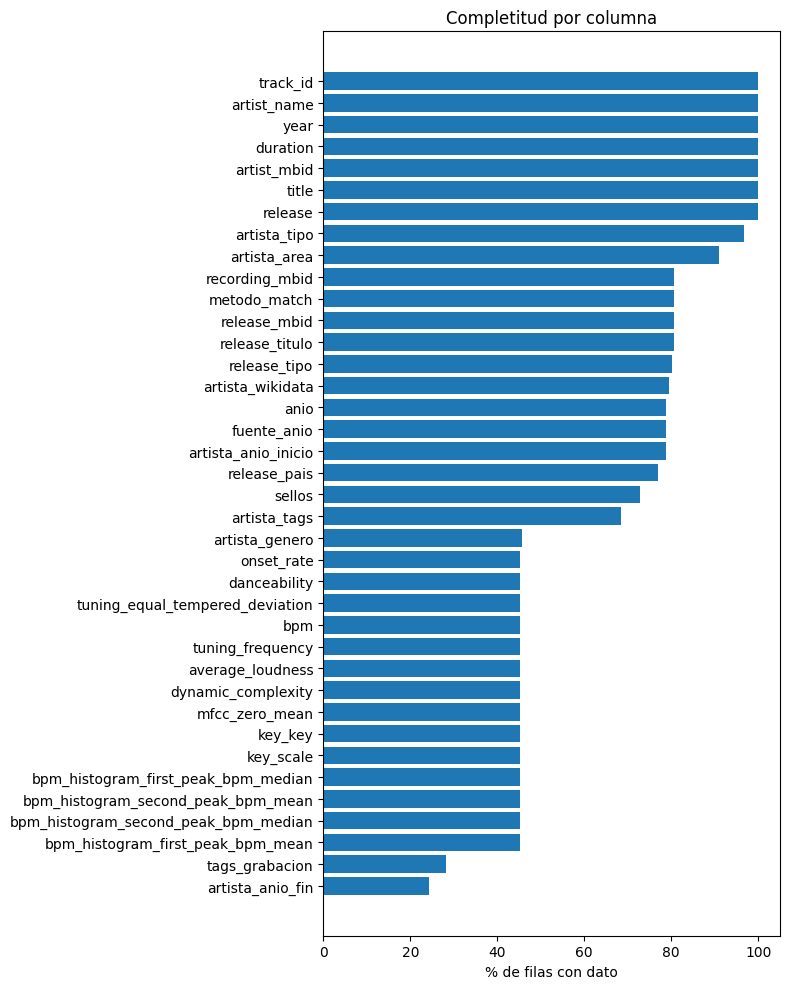

In [4]:
pct = df.notna().mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(pct.index, pct.values)
ax.set_xlabel("% de filas con dato")
ax.set_title("Completitud por columna")
plt.tight_layout()
plt.show()

In [5]:
pct.round(1).sort_values(ascending=False)

track_id                                100.0
artist_name                             100.0
year                                    100.0
duration                                100.0
artist_mbid                             100.0
title                                   100.0
release                                 100.0
artista_tipo                             96.7
artista_area                             90.9
recording_mbid                           80.7
metodo_match                             80.7
release_mbid                             80.7
release_titulo                           80.7
release_tipo                             80.1
artista_wikidata                         79.6
artista_anio_inicio                      78.9
anio                                     78.9
fuente_anio                              78.9
release_pais                             76.9
sellos                                   72.8
artista_tags                             68.5
artista_genero                    

## Por fuente

Lo mismo pero agrupado: qué porcentaje de canciones alcanzó cada fuente.
Uso una columna representativa de cada bloque.

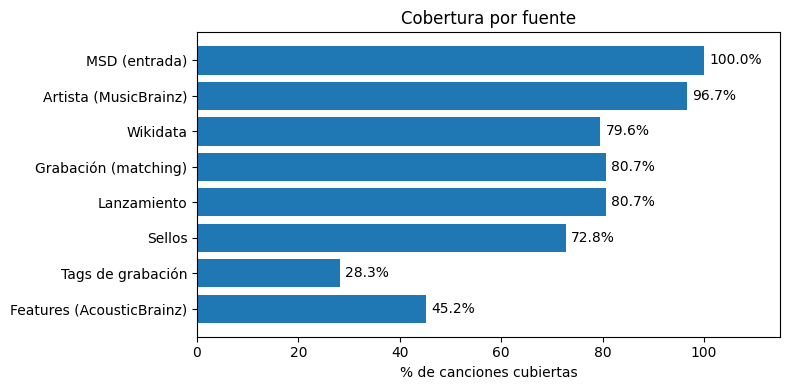

In [6]:
bloques = {
    "MSD (entrada)": "track_id",
    "Artista (MusicBrainz)": "artista_tipo",
    "Wikidata": "artista_wikidata",
    "Grabación (matching)": "recording_mbid",
    "Lanzamiento": "release_mbid",
    "Sellos": "sellos",
    "Tags de grabación": "tags_grabacion",
    "Features (AcousticBrainz)": "bpm",
}
cob = pd.Series({k: df[v].notna().mean() * 100 for k, v in bloques.items()})

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cob.index[::-1], cob.values[::-1])
ax.set_xlabel("% de canciones cubiertas")
ax.set_title("Cobertura por fuente")
for i, v in enumerate(cob.values[::-1]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

## El año: cuántos se recuperaron

En el MSD `year == 0` significa "desconocido". Después de cruzar con MusicBrainz
la columna `anio` debería tener bastantes más años que la original.

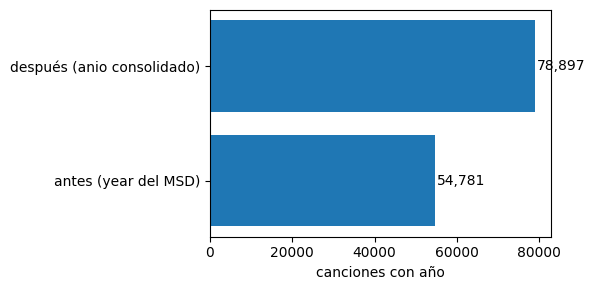

venían con año: 54,781
recuperados de MusicBrainz: 24,116
siguen sin año: 21,103


In [7]:
con_msd = (df["year"] != 0).sum()
sin_msd = (df["year"] == 0).sum()
recuperados = ((df["year"] == 0) & df["anio"].notna() & (df["anio"] != 0)).sum()
sin_anio = sin_msd - recuperados

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["antes (year del MSD)", "después (anio consolidado)"],
        [con_msd, con_msd + recuperados])
ax.set_xlabel("canciones con año")
for i, v in enumerate([con_msd, con_msd + recuperados]):
    ax.text(v + 500, i, f"{v:,}", va="center")
plt.tight_layout()
plt.show()

print(f"venían con año: {con_msd:,}")
print(f"recuperados de MusicBrainz: {recuperados:,}")
print(f"siguen sin año: {sin_anio:,}")

In [8]:
# de dónde salió el año consolidado
df["fuente_anio"].value_counts(dropna=False)

fuente_anio
msd            54781
musicbrainz    24116
NaN            21103
Name: count, dtype: int64